Module importing

In [11]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset

sys.path.append('D:/ppg_project/code/model_build/my_tool/model')
from unet_lstm_AI import unet_lstm
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
from model_builder import k_fold_training
from performance import performance
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')
from ppg_labeled_load import PPGDataset

Data prepairing

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_3700\2803335453.py:2: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})


254
torch.Size([1, 800])


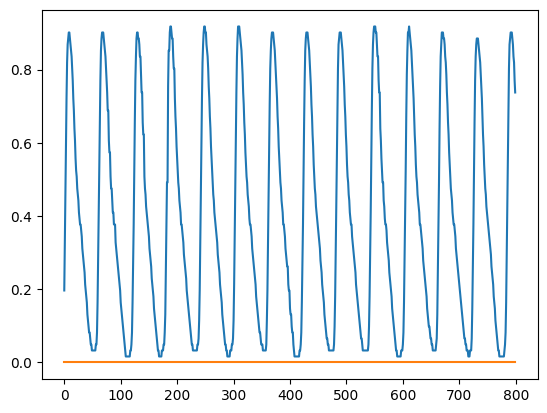

In [12]:
#Import_data
dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})
print(dataset.count)

print(dataset[111][0].shape)
for i in [22]:
    plt.plot(dataset[i][0].numpy().flatten())
    plt.plot(dataset[i][1].numpy().flatten())

# plt.plot(dataset[0][1].numpy())
    plt.show()

Training

In [16]:
# trainning test cho code AI
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {
    "Serie length":         800,
    "Input size":           1,
    "Hidden size":          512,
    "Number layers":        2,
    "Encoder structure":    [1,64,128,256,512], 
    "Decoder structure":    [512,256,128,64,1],
    "Kernel size":          [3,3,3,3,3,3,3,3,3],
    "Kernel encoder":       [8,8,8,8],
    "Kernel decoder":       [4,4,4,4],
    "Stride":               [2,2,2,2],
    "Activate function":    nn.ReLU(),  # ✅ Đổi từ Tanh → ReLU
    "Output activation":    None  # ✅ THÊM: Không giới hạn output range
}

model = unet_lstm(para).to(device)  # ✅ THÊM .to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)  # ✅ THÊM weight_decay

# ✅ MSE thay vì L1 (tốt hơn cho signal reconstruction)
criterion = nn.MSELoss()  

builder = k_fold_training(dataset, 1, criterion=criterion)
builder.training(model, device, optimizer, num_epochs=3000, batch=64, visualize=1)

True
Iteration: 1/3000. loss_train: 0.7552318572998047. loss_val: 0
Iteration: 2/3000. loss_train: 0.5954433083534241. loss_val: 0
Iteration: 3/3000. loss_train: 0.5166671276092529. loss_val: 0
Iteration: 4/3000. loss_train: 0.4845384955406189. loss_val: 0
Iteration: 5/3000. loss_train: 0.47231101989746094. loss_val: 0
Iteration: 6/3000. loss_train: 0.4565487205982208. loss_val: 0
Iteration: 7/3000. loss_train: 0.4459386467933655. loss_val: 0
Iteration: 8/3000. loss_train: 0.4367696940898895. loss_val: 0
Iteration: 9/3000. loss_train: 0.430042028427124. loss_val: 0
Iteration: 10/3000. loss_train: 0.4217350482940674. loss_val: 0
Iteration: 11/3000. loss_train: 0.4169991910457611. loss_val: 0
Iteration: 12/3000. loss_train: 0.41136640310287476. loss_val: 0
Iteration: 13/3000. loss_train: 0.4067160189151764. loss_val: 0
Iteration: 14/3000. loss_train: 0.4020281434059143. loss_val: 0
Iteration: 15/3000. loss_train: 0.3992505371570587. loss_val: 0
Iteration: 16/3000. loss_train: 0.391141057

In [19]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {"Serie length":         800,
            "Input size":           1,
            "Hidden size":          512,
            "Number layers":        2,
            "Encoder structure":    [1,64,128,256,512], 
            "Decoder structure":    [512,256,128,64,100],
            "Kernel size":          [3,3,3,3,3,3,3,3,3],
            "Kernel encoder":       [8,8,8,8],
            "Kernel decoder":       [4,4,4,4],
            "Stride":               [2,2,2,2],
            "Activate function":    nn.Tanh()
    }

model = unet_lstm(para)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# builder = k_fold_training(train_data, 1, criterion = nn.L1Loss())
builder = k_fold_training(dataset,1,criterion = nn.L1Loss())
builder.training(model,device,optimizer,num_epochs=3000,batch=64,visualize=1)

True


d:\venv\Lib\site-packages\torch\nn\modules\loss.py:132: UserWarning: Using a target size (torch.Size([64, 1, 800])) that is different to the input size (torch.Size([64, 100, 800])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
d:\venv\Lib\site-packages\torch\nn\modules\loss.py:132: UserWarning: Using a target size (torch.Size([62, 1, 800])) that is different to the input size (torch.Size([62, 100, 800])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Iteration: 1/3000. loss_train: 0.5800848007202148. loss_val: 0
Iteration: 2/3000. loss_train: 0.5543668270111084. loss_val: 0
Iteration: 3/3000. loss_train: 0.5323588252067566. loss_val: 0
Iteration: 4/3000. loss_train: 0.5099623799324036. loss_val: 0
Iteration: 5/3000. loss_train: 0.48732060194015503. loss_val: 0
Iteration: 6/3000. loss_train: 0.46563830971717834. loss_val: 0
Iteration: 7/3000. loss_train: 0.4454494118690491. loss_val: 0
Iteration: 8/3000. loss_train: 0.42602336406707764. loss_val: 0
Iteration: 9/3000. loss_train: 0.40800848603248596. loss_val: 0
Iteration: 10/3000. loss_train: 0.3917200267314911. loss_val: 0
Iteration: 11/3000. loss_train: 0.3762132525444031. loss_val: 0
Iteration: 12/3000. loss_train: 0.36304670572280884. loss_val: 0
Iteration: 13/3000. loss_train: 0.35155919194221497. loss_val: 0
Iteration: 14/3000. loss_train: 0.3399370312690735. loss_val: 0
Iteration: 15/3000. loss_train: 0.33398446440696716. loss_val: 0
Iteration: 16/3000. loss_train: 0.32342755

Performance

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_3700\2692554754.py:2: SyntaxWarning: invalid escape sequence '\p'
  test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")


Max loss:  0.99947554
Mean loss:  0.27214703
Min loss:  0.0
Number of test:  84


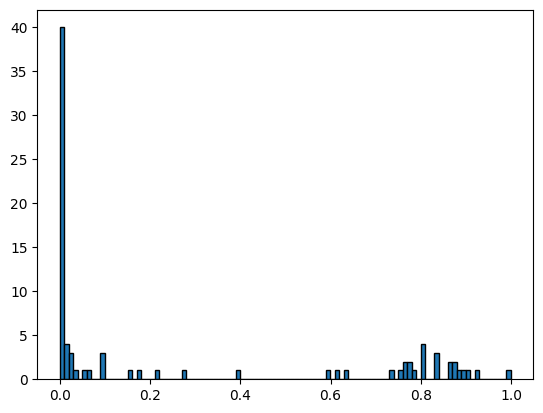

0.15745111


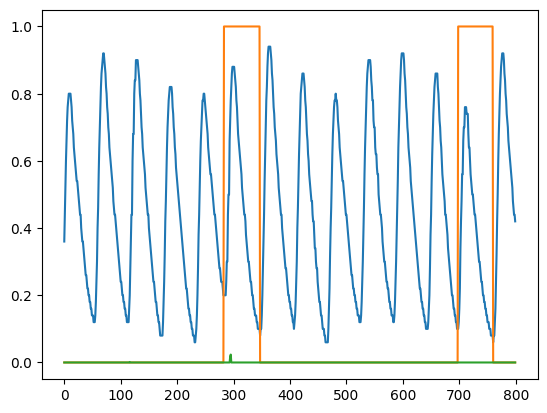

0.77642864


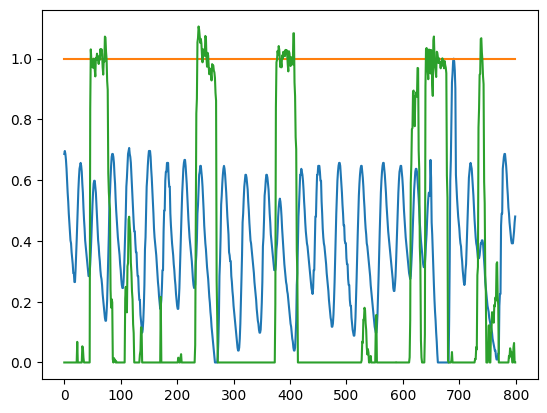

0.80726224


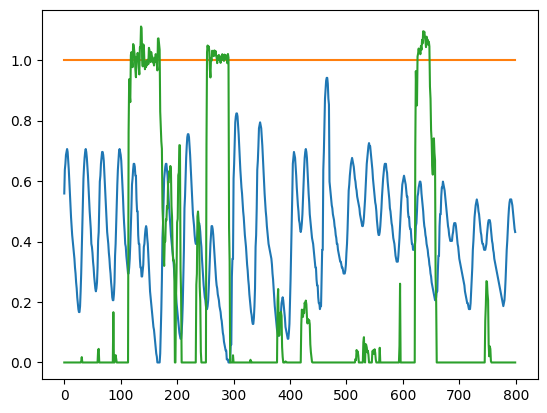

3.197182e-05


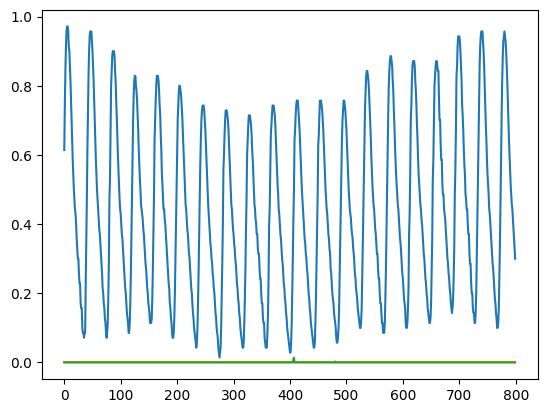

0.00012543441


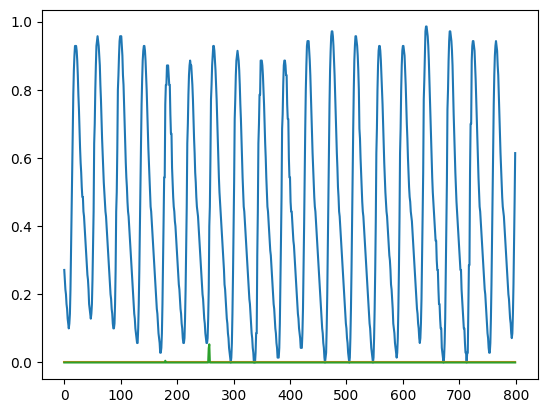

0.0


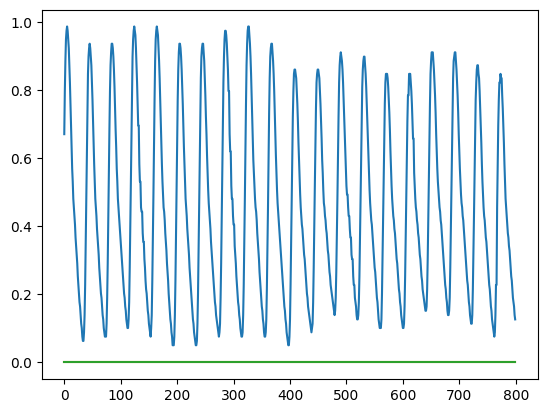

2.3068698e-05


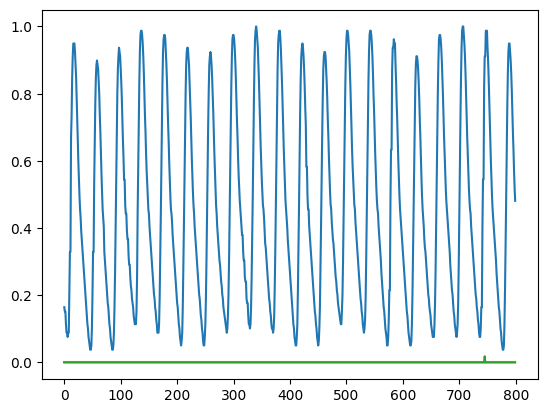

0.0


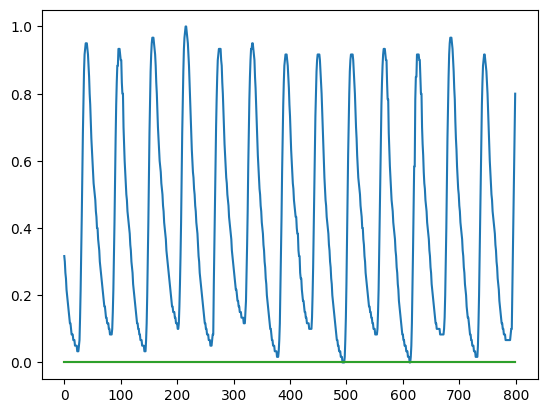

0.0


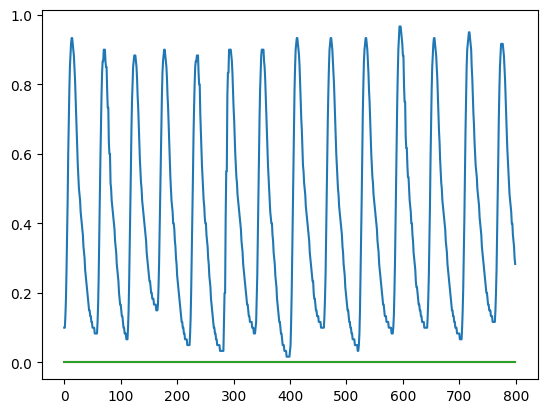

3.1737854e-05


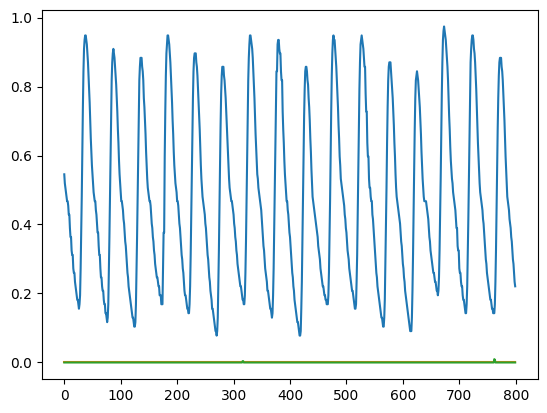

2.212115e-05


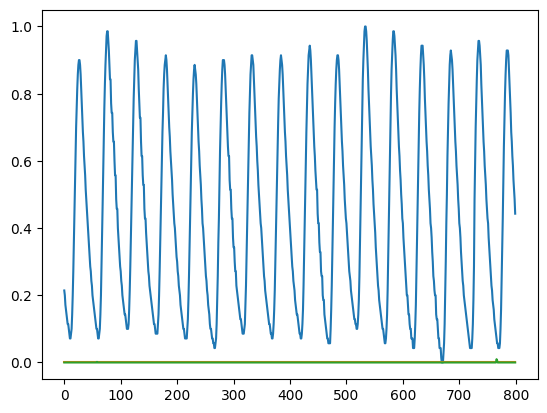

0.0


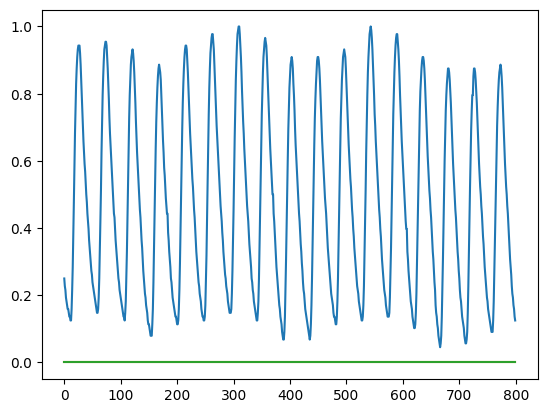

0.009273178


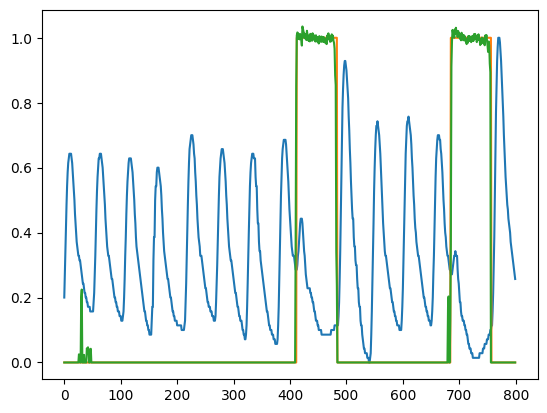

0.05731694


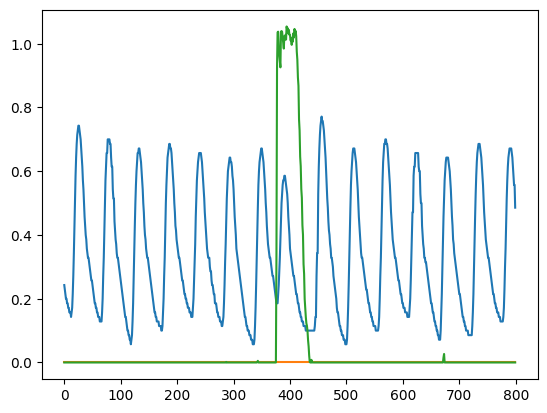

0.008080657


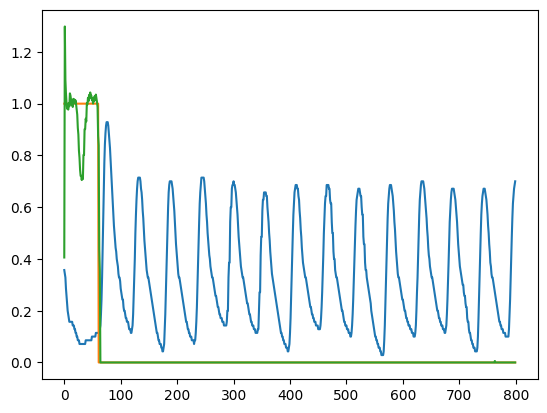

0.0


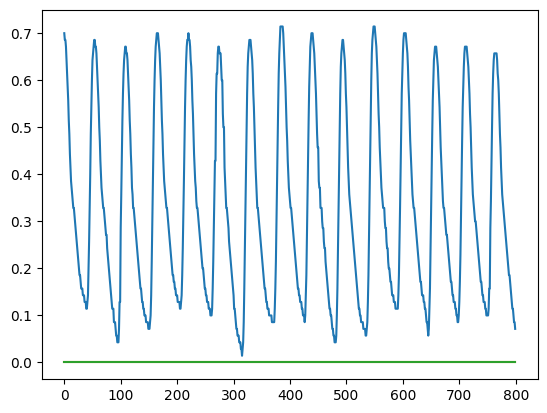

0.90279514


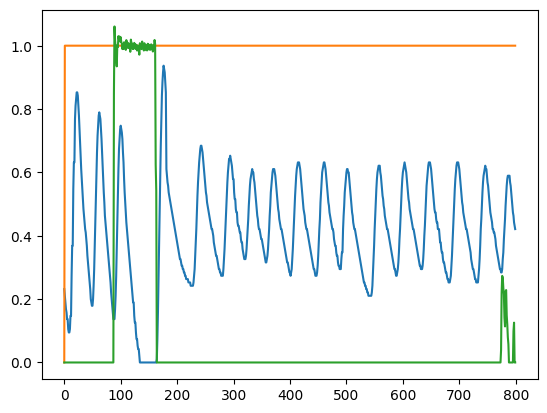

0.887849


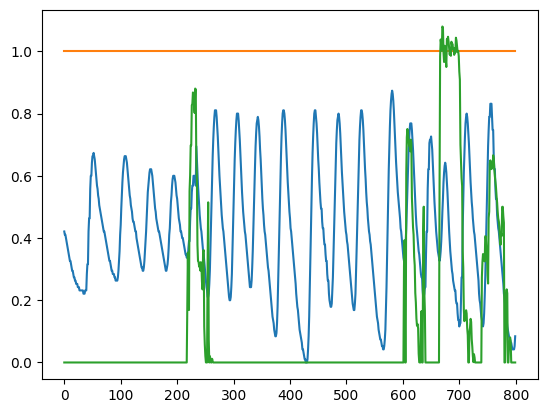

0.80814534


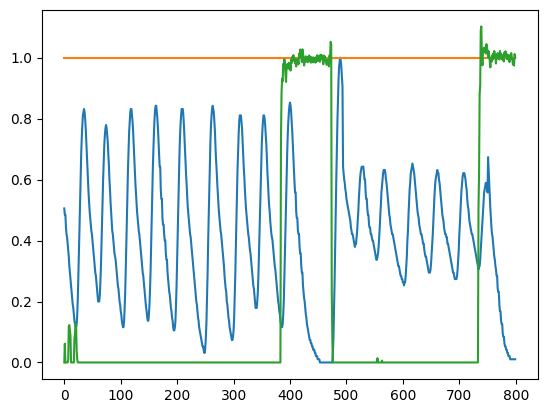

0.80079925


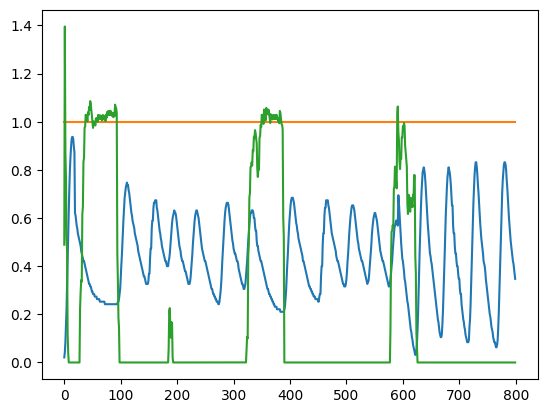

0.83669096


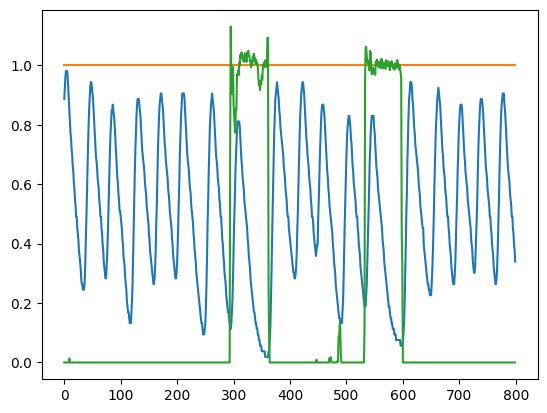

1.3708632e-05


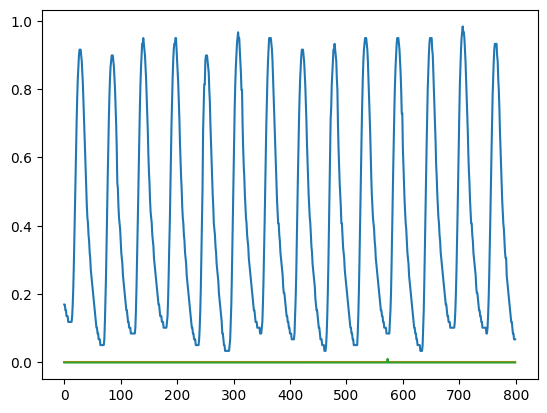

9.89041e-05


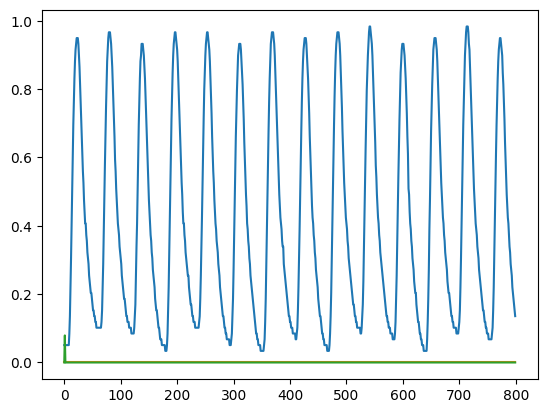

5.5922706e-06


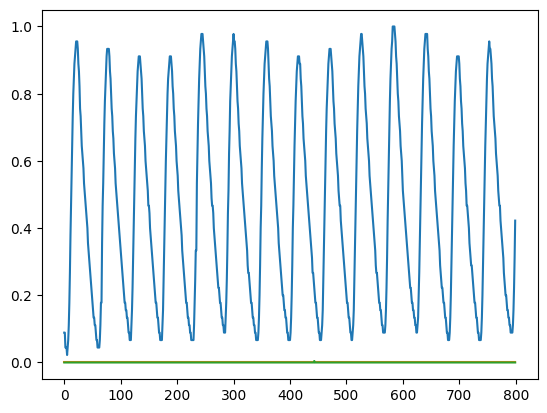

9.2047274e-05


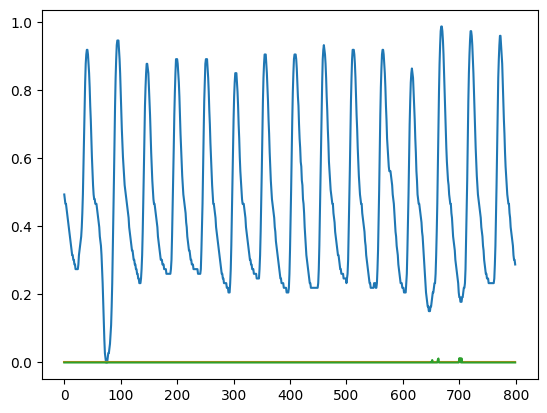

3.6804242e-05


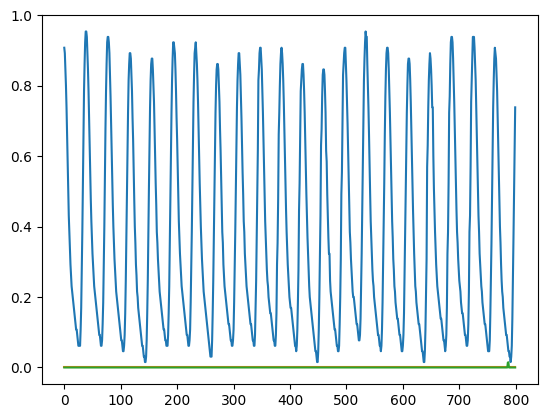

0.8930668


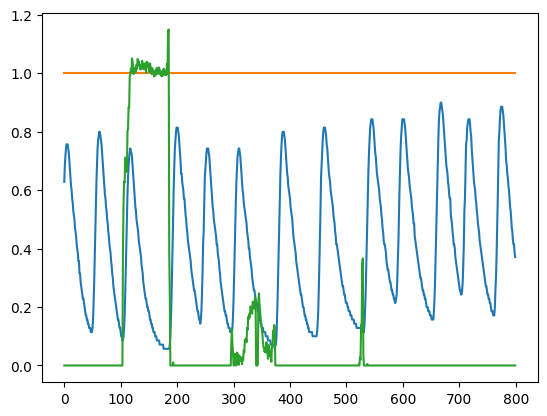

0.0


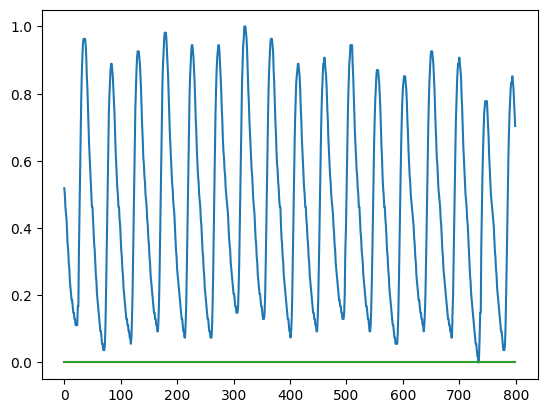

4.695491e-06


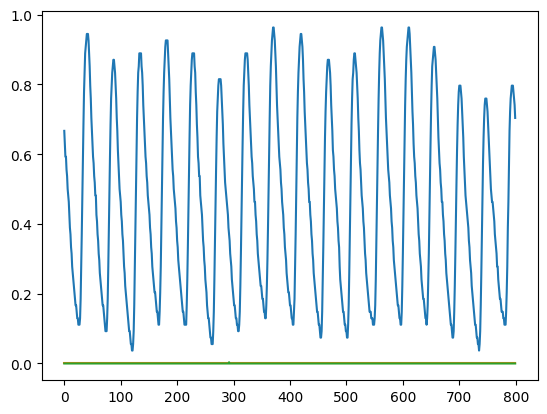

0.59009176


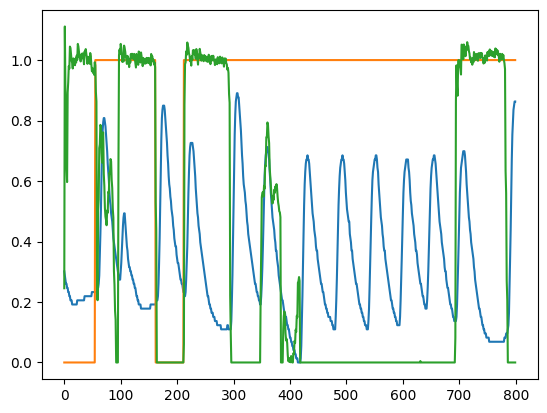

0.0


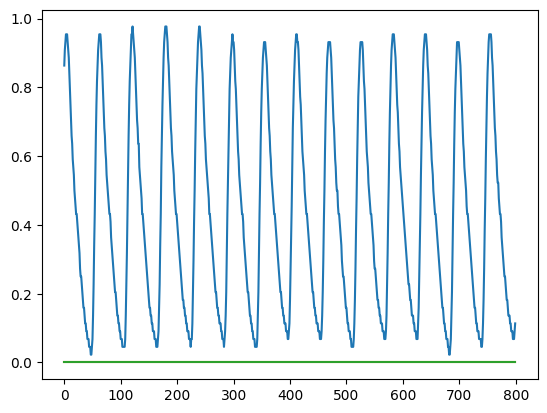

5.7048455e-05


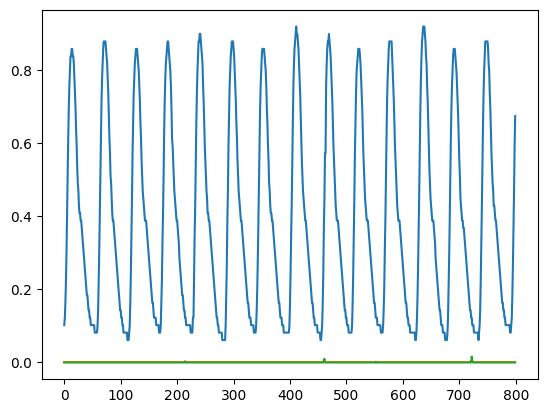

9.137649e-05


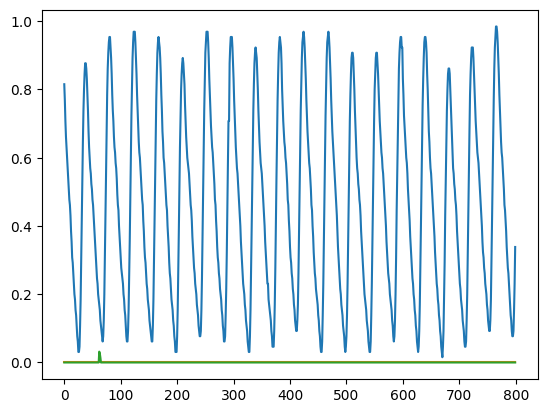

0.0


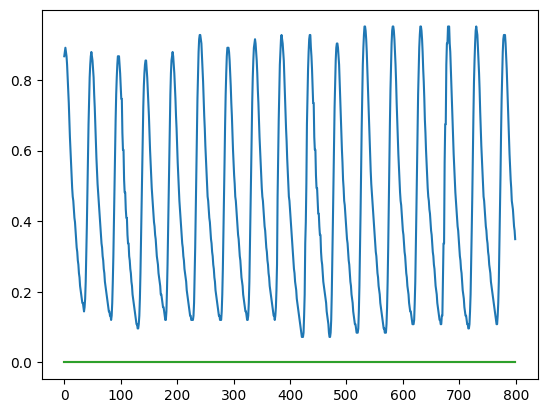

0.0


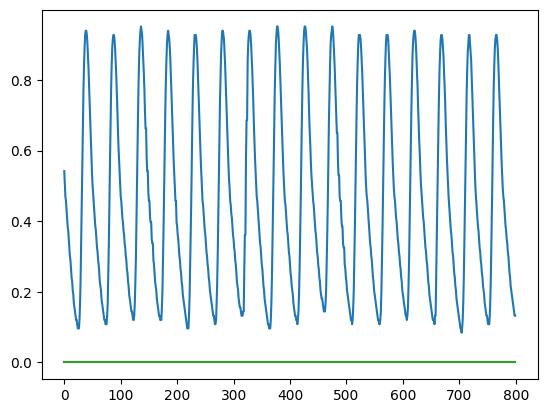

5.9649433e-06


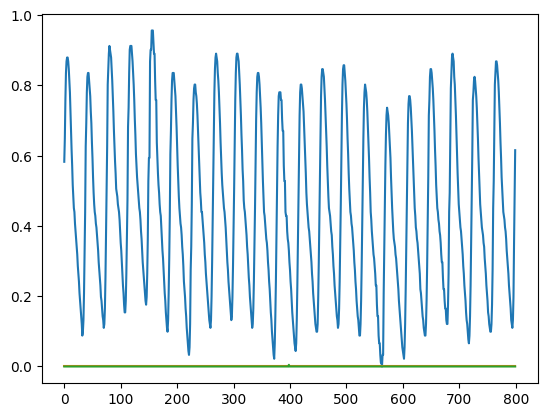

6.0260478e-05


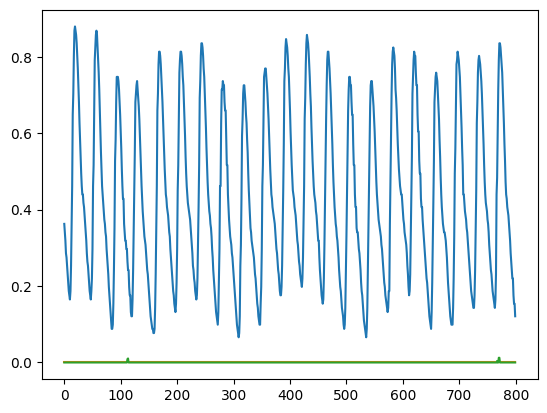

2.4711153e-06


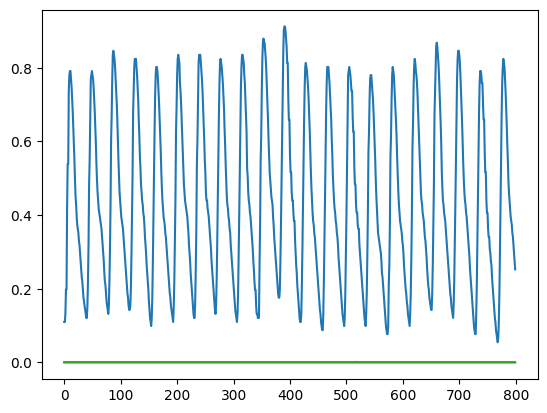

2.8506214e-05


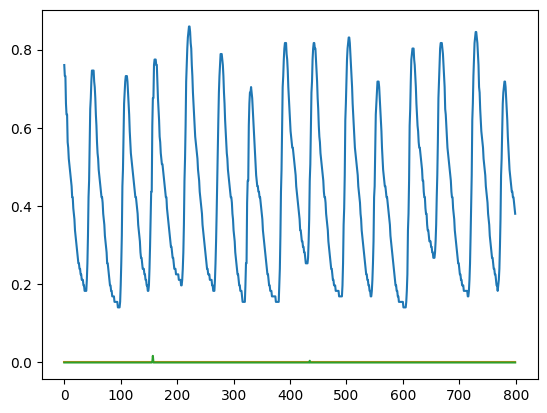

0.8008531


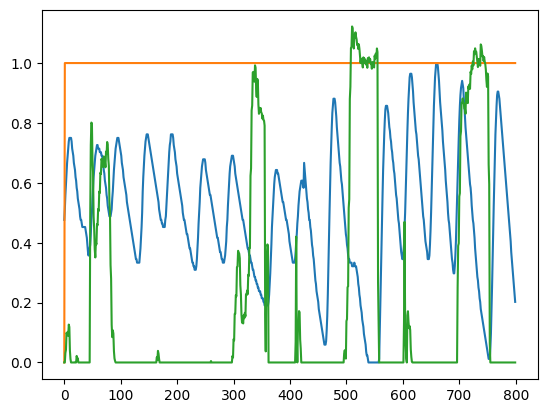

0.0


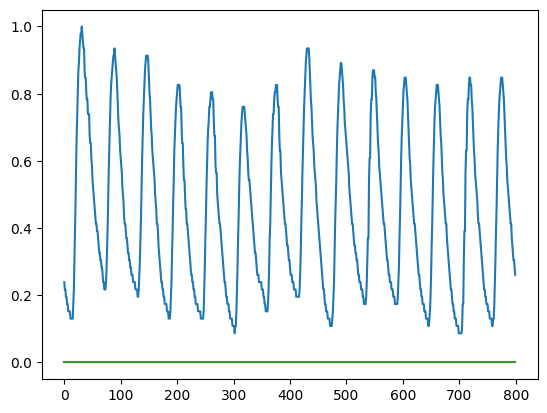

0.7320931


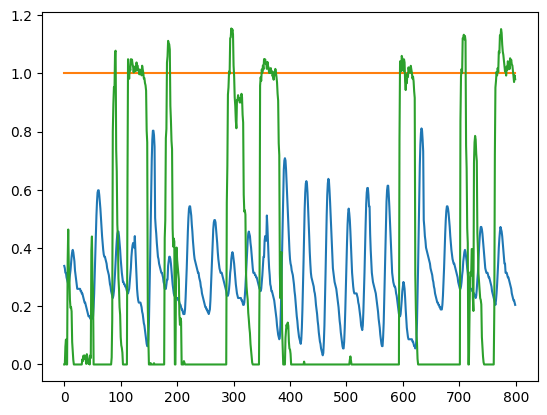

0.8728537


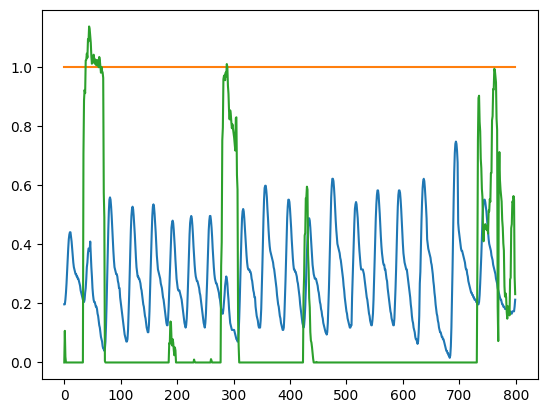

6.499178e-05


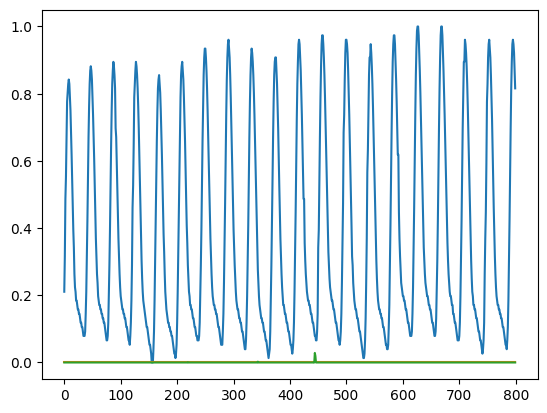

0.0046560382


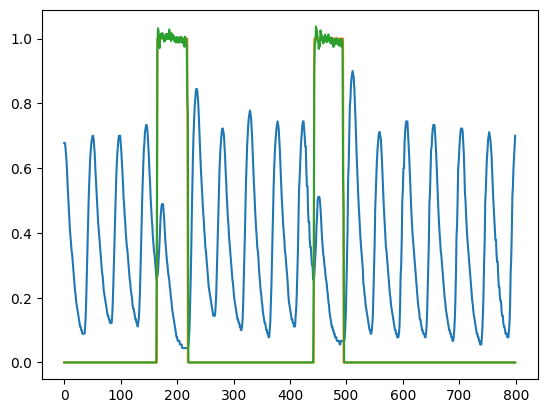

0.019606616


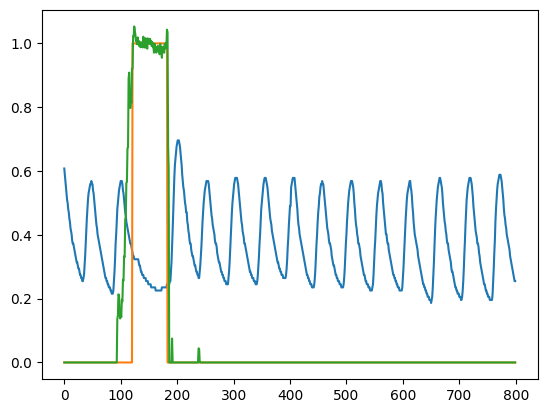

0.003037416


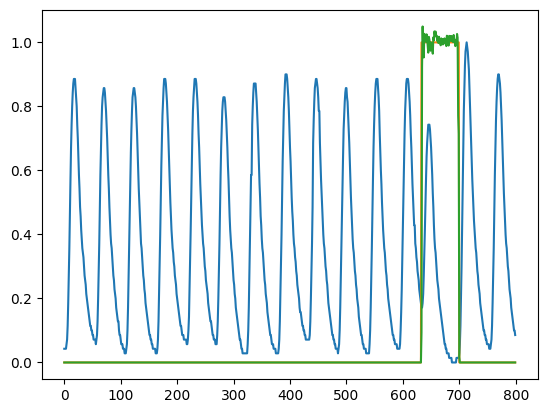

0.76287746


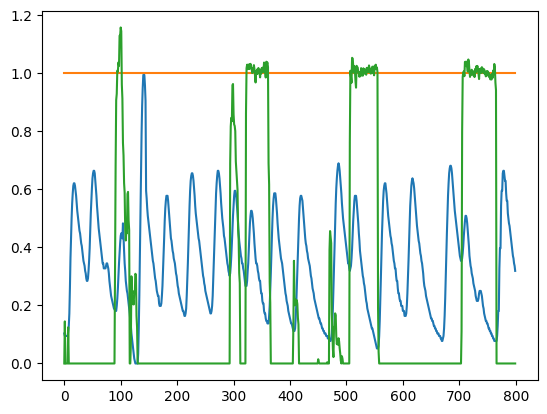

0.7504812


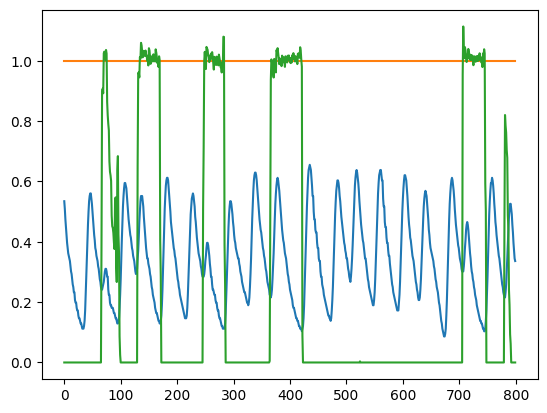

0.02446825


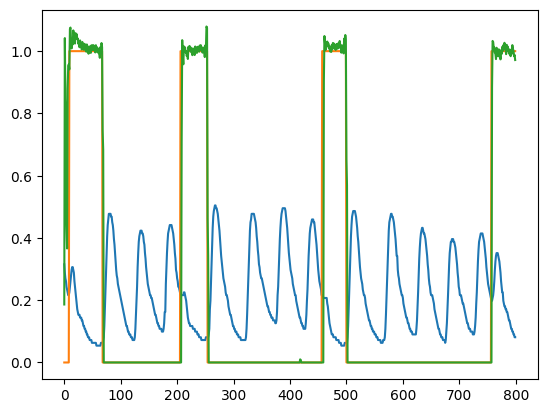

0.036218505


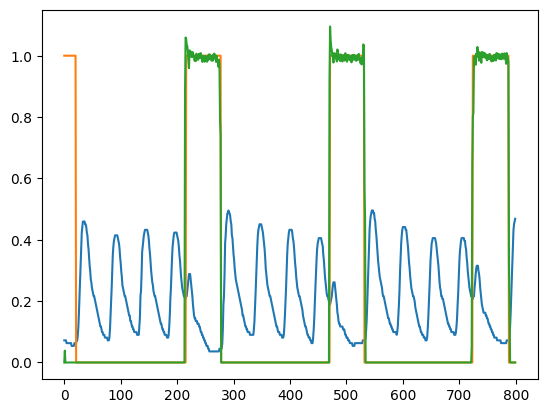

0.09742292


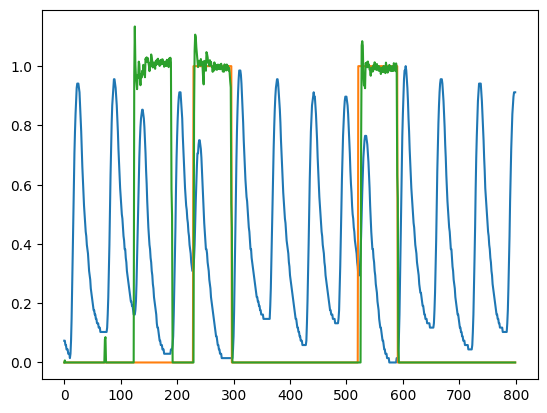

0.0


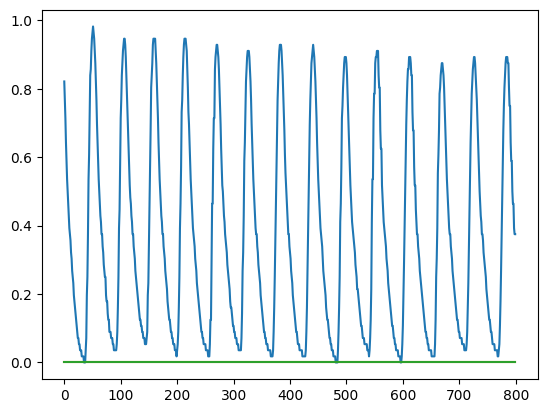

0.0


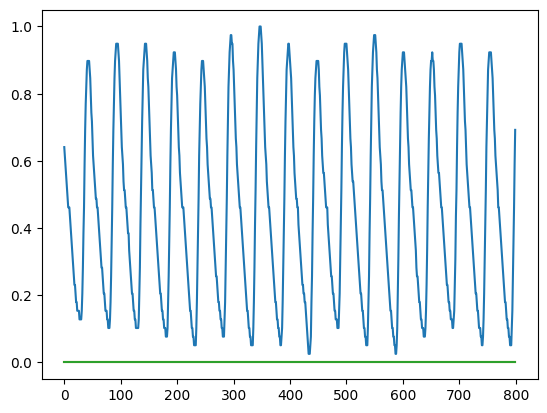

0.0


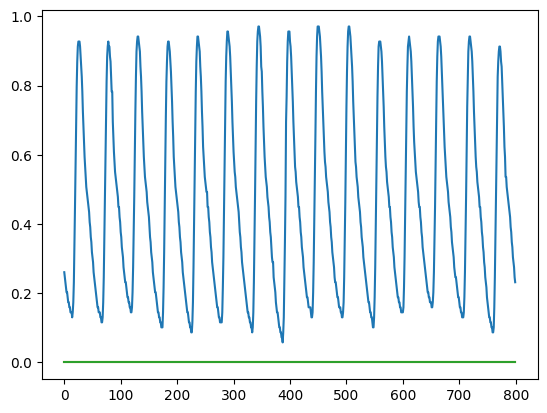

0.63942826


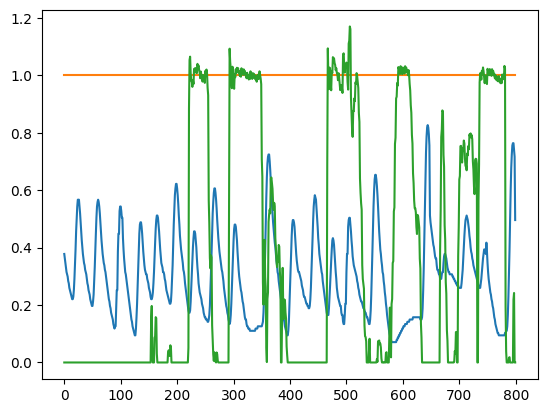

0.61205894


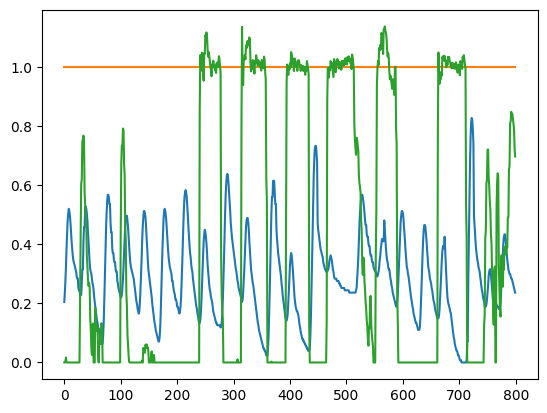

0.012823825


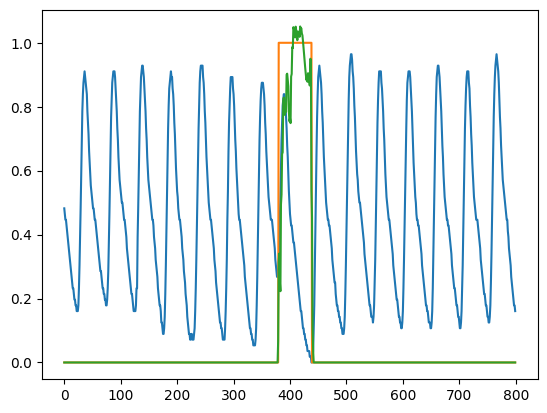

0.83035934


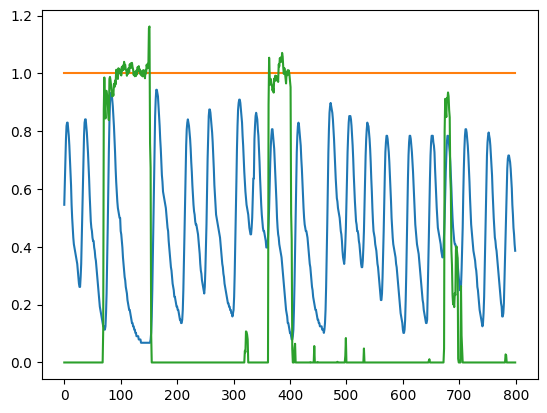

0.7622186


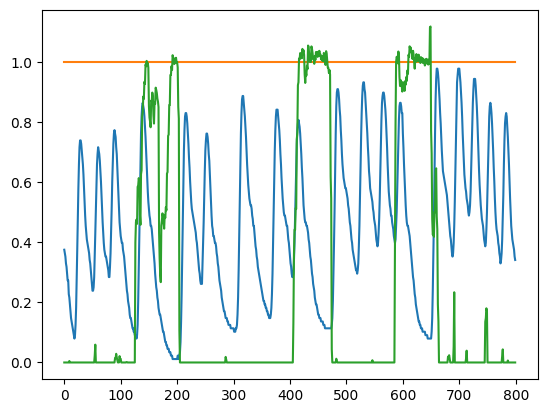

0.86498916


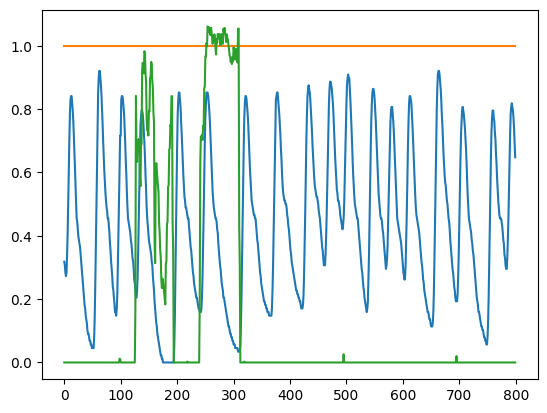

0.025763974


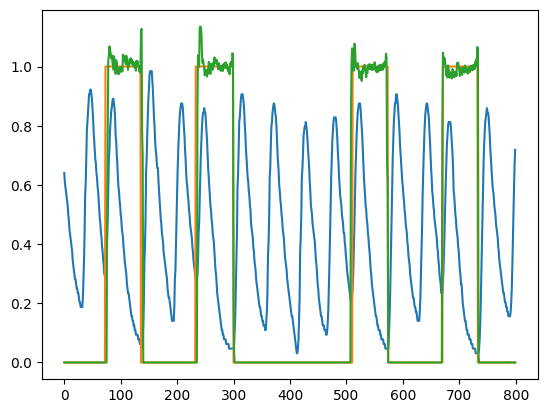

0.39833894


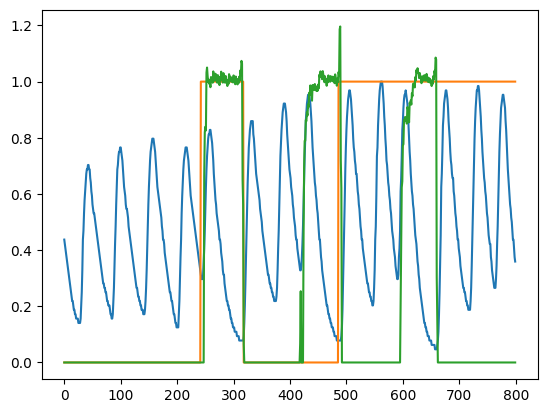

0.017076049


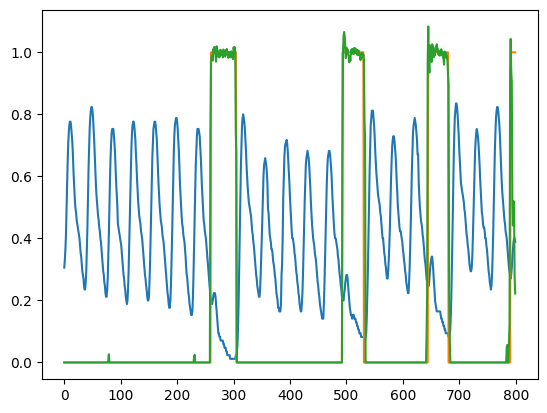

0.21278545


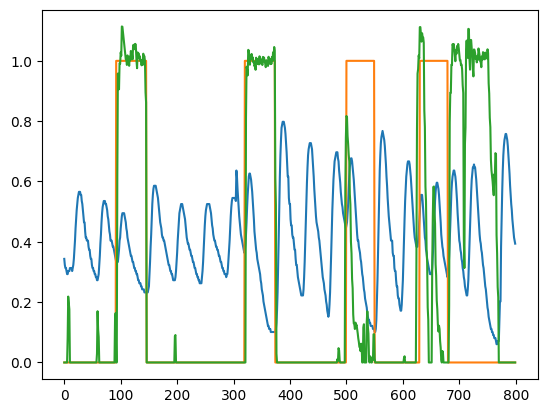

5.8114965e-06


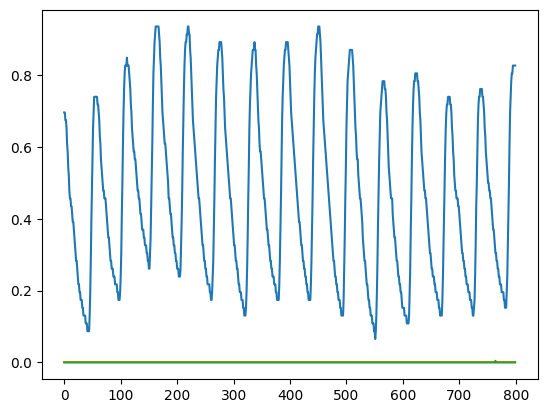

0.78727734


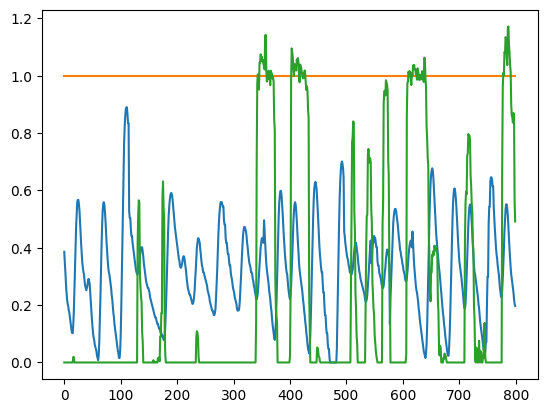

0.17717247


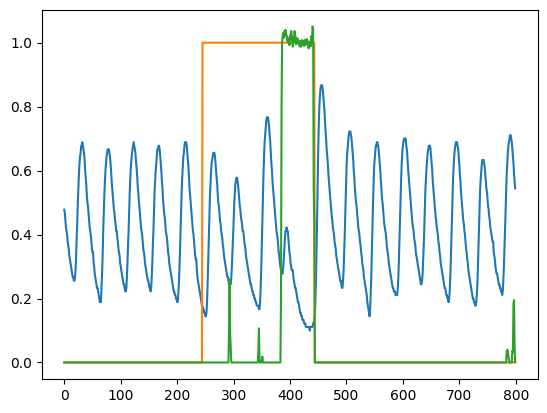

0.27559382


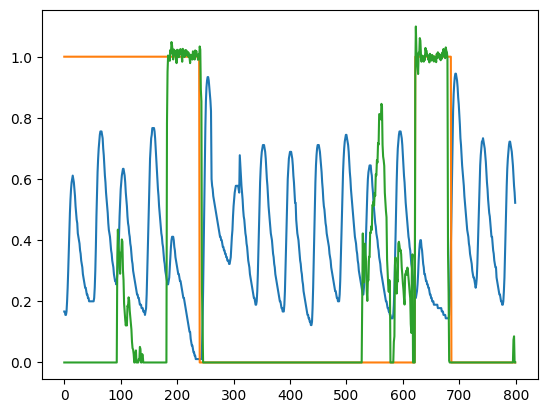

0.009187139


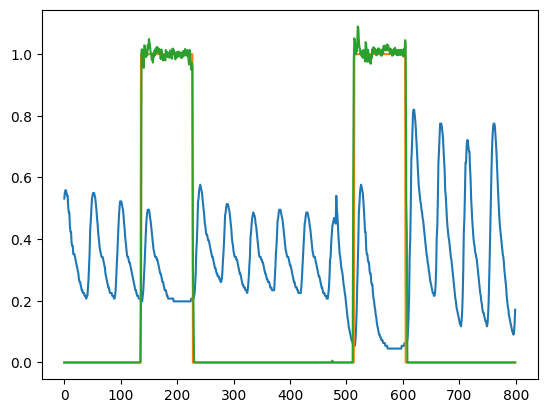

0.008285849


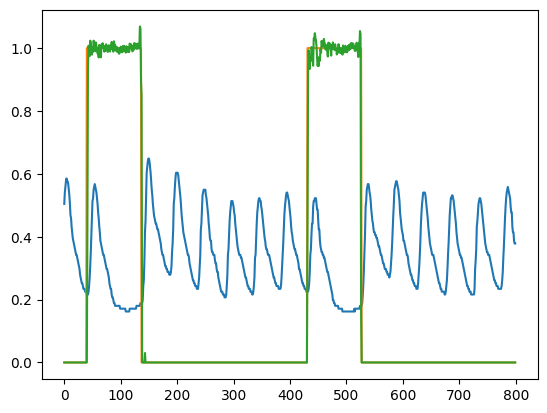

0.007881964


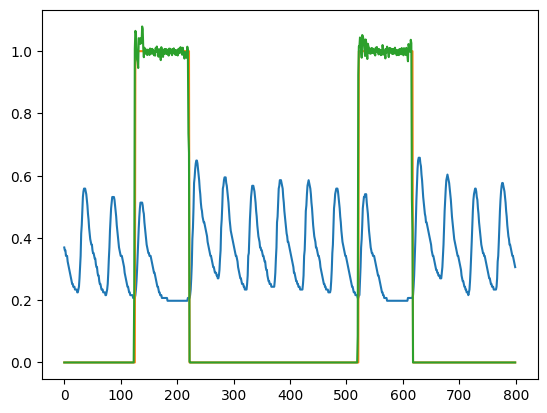

0.0048468504


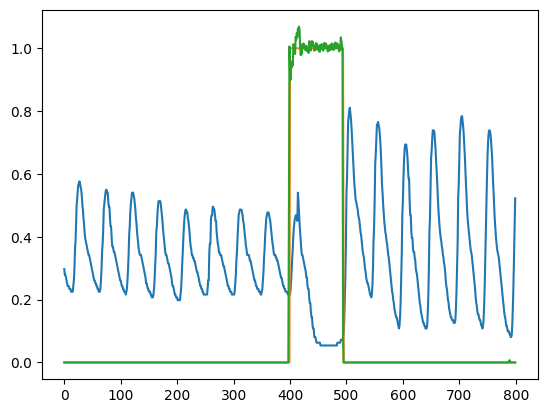

0.06636596


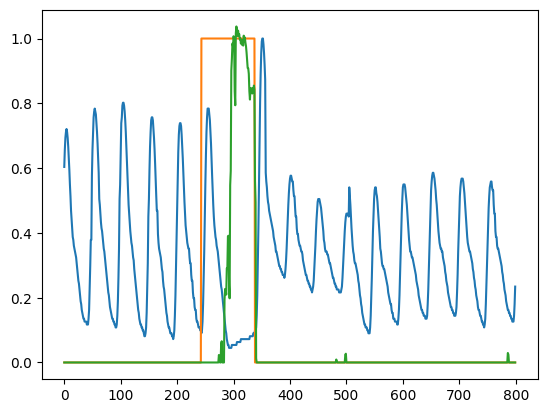

0.87749505


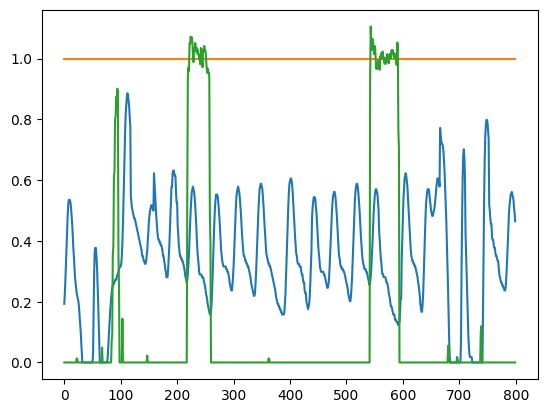

0.8308262


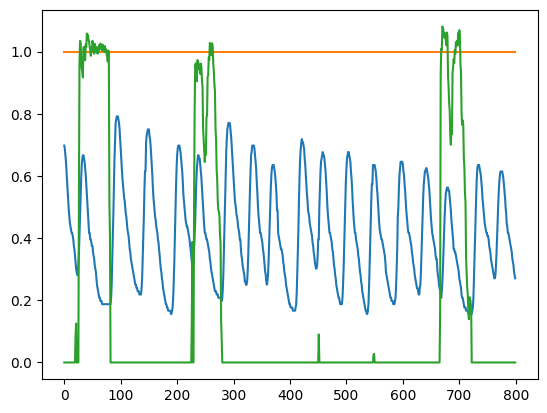

0.9277995


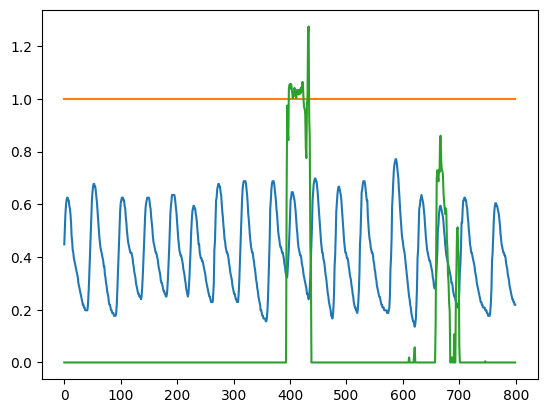

0.99947554


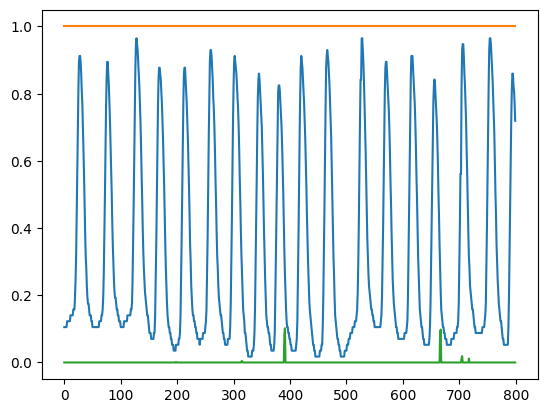

0.098396815


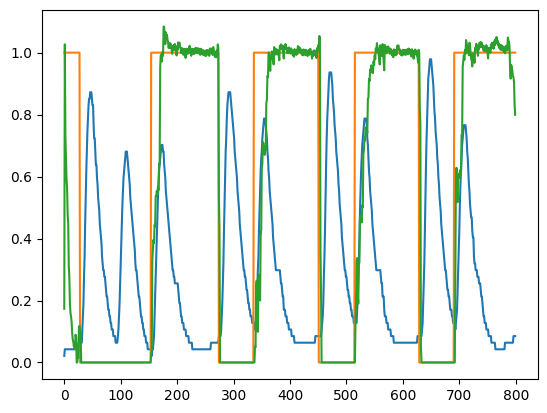

0.09820255


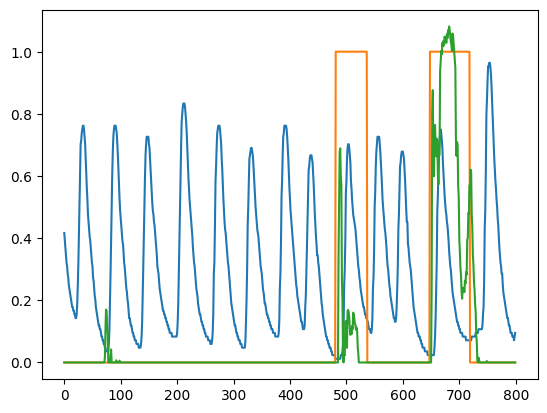

0.7703736


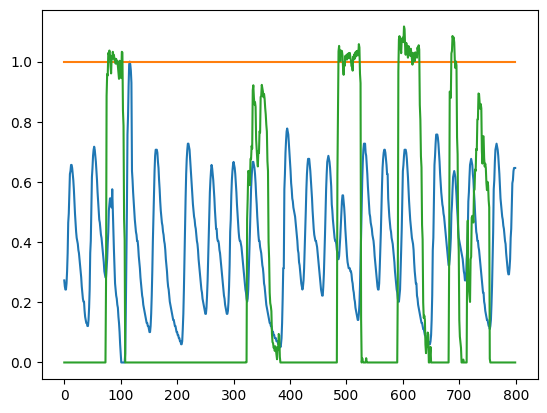

0.8671172


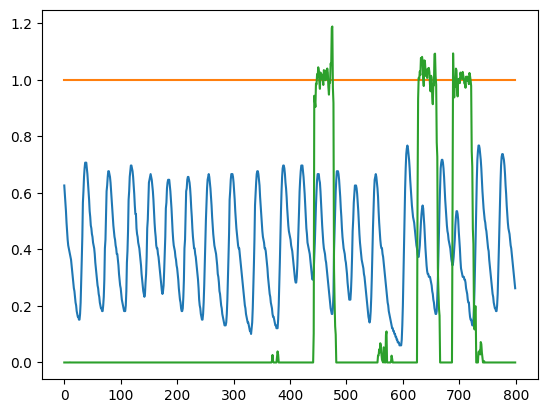

0.013718177


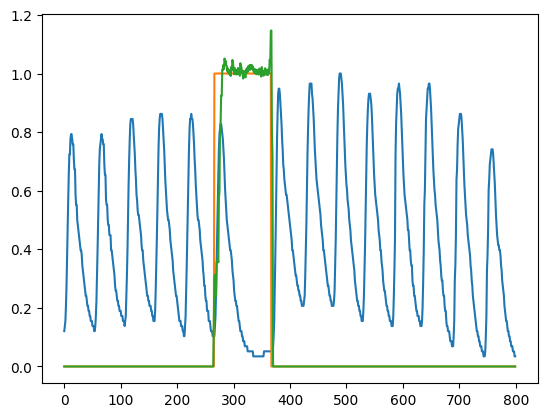

0.02386781


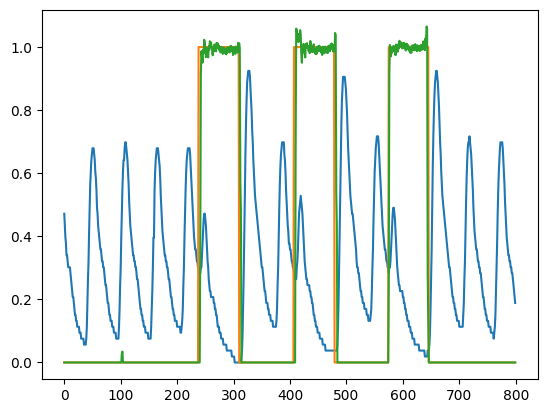

In [17]:
shower = performance()
test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")
shower.test(model,device,test_data,per_fnc = "series")
criterion = nn.L1Loss()
for i in range(len(test_data)):
    output = torch.stack([test_data[i][1]]).to(device)
    input = torch.stack([test_data[i][0]]).to(device)
    y_hat = model.forward(input)
    loss = criterion(y_hat,output)
    # if loss.cpu().detach().numpy()<0.3:
    print(loss.cpu().detach().numpy())
    plt.plot(input.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(output.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(y_hat.cpu().detach().numpy().flatten()[0:1000])
    plt.show()